# ICT-3 — Robustesse & délai de gratification : étude quantitative

> Série **ICT** (*Integrated Causal Trajectories*, Epic [#4588](https://github.com/jsboige/CoursIA/issues/4588)).
> Prérequis : [ICT-0 (cadrage)](ICT-0-Framing.md) et [ICT-2 (modèle de base)](ICT-2-SelfSortingMorphogenesis.ipynb).

Le notebook [ICT-2](ICT-2-SelfSortingMorphogenesis.ipynb) a introduit le **tri vu-cellule** (*cell-eye-view*)
d'après Zhang, Goldstein & Levin (2025, [arXiv:2401.05375](https://arxiv.org/abs/2401.05375)) :
chaque élément d'un tableau devient une **cellule autonome** qui applique localement la règle de son
*algotype* (`bubble` regarde à droite, `insertion` regarde à gauche). L'ordre global **émerge** des
décisions locales — une morphogenèse minimale, entièrement calculable.

ICT-2 a *montré* deux compétences inattendues du modèle (sur un exemple chacune) :

- **robustesse** — le système se trie malgré des cellules endommagées (`frozen`) ;
- **délai de gratification** — l'ordre local se dégrade transitoirement au service du progrès global.

ICT-3 **les mesure**. On passe de l'anecdote (« regardez, ça marche encore ») à l'**étude expérimentale** :

1. **Dégradation gracieuse** — balayage du taux de lésion (0 → 50 %), croisé avec l'algotype et le
   régime de gel (`passive` vs `obstacle`), moyenné sur plusieurs graines. *À quelle vitesse la
   compétence se dégrade-t-elle quand on casse de plus en plus de cellules ?*
2. **Temps de récupération** — distribution du temps de retour à l'ordre après une lésion exogène,
   en fonction du régime et du taux de gel. *Le système répare-t-il, et combien de pas cela coûte-t-il ?*
3. **Quantification du délai de gratification** — comptage des épisodes de recul local, comparé entre
   `bubble` et `insertion`. *Quel algotype « sacrifie » le plus pour avancer ?*

Le fil méthodologique de la série (cf [ICT-0](ICT-0-Framing.md)) : **exécuter, mesurer, narrer le
résultat réel** — pas le résultat espéré.

**Pourquoi ces deux compétences constituent un _test d'intelligence_.** Avant de les mesurer,
rappelons ce qu'on mesure au juste. Michael Levin — dont le programme de l'**intelligence diverse**
a inspiré le modèle vu-cellule de Zhang, Goldstein & Levin — propose une définition *opérationnelle*
de l'intelligence : *« Intelligence is the degree of ingenuity that it has in overcoming barriers
between it and its goal »*. L'intelligence se lit donc au degré d'**ingéniosité à franchir les
barrières** entre un système et son but, et le protocole qui la révèle est limpide : **placer une
barrière, observer la réponse**.

C'est exactement le plan de ce notebook. Les cellules `frozen`, le régime `obstacle` et la lésion
exogène **sont les barrières** ; la dégradation gracieuse (§1), le temps de récupération (§2) et le
comptage du délai de gratification (§3) **mesurent l'ingéniosité** du substrat à les contourner — le
vocabulaire cognitif n'est pas décoratif, il nomme la grandeur que chaque expérience sonde. Cadrage
complet (spectre de la cognition, cône de lumière cognitif, « revendications-protocole ») :
**[ICT-0 — Pourquoi parler de « compétences » ?](ICT-0-Framing.md)**.

## 0. Mise en place

On réutilise le package `ict/` livré avec ICT-2 (aucune dépendance lourde : bibliothèque standard +
`numpy`/`matplotlib` pour les figures). `SelfSortingArray` porte le modèle vu-cellule ; le module
`sorting_metrics` fournit `sortedness`, `monotonicity_curve`, `delayed_gratification_events`,
`recovery_time`, etc.

In [1]:
import os
import sys
import random

import numpy as np
import matplotlib.pyplot as plt

# le package ict/ est a cote de ce notebook
sys.path.insert(0, os.path.abspath("."))

from ict.self_sorting import SelfSortingArray, ALGOTYPES
from ict import sorting_metrics as m

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

N = 40            # taille du tableau d'etude
BASE_SEED = 7     # graine de reference pour les configurations reproductibles
print(f"Algotypes disponibles : {ALGOTYPES}")
print(f"Tableau d'etude : N = {N} elements")

Algotypes disponibles : ('bubble', 'insertion')
Tableau d'etude : N = 40 elements


In [2]:
def make_values(n, seed):
    # une permutation aleatoire reproductible de 0..n-1
    return random.Random(seed).sample(range(n), n)

def frozen_mask(n, fraction, seed):
    # selectionne round(fraction*n) positions gelees, reproductible par seed
    k = round(fraction * n)
    idx = set(random.Random(seed).sample(range(n), k))
    return [i in idx for i in range(n)]

# verification rapide : 25% de N=40 -> 10 cellules gelees
demo_mask = frozen_mask(N, 0.25, seed=0)
print(f"frozen_mask(0.25) -> {sum(demo_mask)} cellules gelees sur {N}")

frozen_mask(0.25) -> 10 cellules gelees sur 40


## 1. Dégradation gracieuse de la compétence de tri

**Question.** Quand on augmente la proportion de cellules cassées, le tri ne s'effondre pas d'un coup —
il se *dégrade*. Mais comment ? Linéairement ? Avec un seuil critique ? Et le **régime de gel** change-t-il
la donne ?

Deux régimes (cf [ICT-2](ICT-2-SelfSortingMorphogenesis.ipynb)) :

- **`passive`** (fidèle au papier) — la cellule gelée n'agit pas mais reste un *passager* : une voisine
  saine peut la déplacer. Le système reste fluide.
- **`obstacle`** — la cellule gelée est en plus *infranchissable* : elle agit comme un **mur** qui découpe
  le tableau en segments triés indépendamment.

On balaye le taux de lésion de 0 à 50 %, pour chaque algotype et chaque régime, et on mesure la
**sortedness finale** (1.0 = parfaitement trié), moyennée sur plusieurs graines.

In [3]:
DAMAGE_LEVELS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
SEEDS = [0, 1, 7, 42, 99]   # 5 graines -> moyenne + ecart-type

def final_sortedness(fraction, algotype, mode, seed):
    vals = make_values(N, seed)
    fz = frozen_mask(N, fraction, seed=1000 + seed)  # masque decorrele des valeurs
    arr = SelfSortingArray(
        vals,
        algotypes=[algotype] * N,
        frozen=fz,
        seed=seed,
        frozen_mode=mode,
    ).run(max_steps=40000, record=False)
    return m.sortedness(arr.values)

results = {}  # (algotype, mode) -> (means, stds)
for algotype in ALGOTYPES:
    for mode in ("passive", "obstacle"):
        means, stds = [], []
        for frac in DAMAGE_LEVELS:
            vals = [final_sortedness(frac, algotype, mode, s) for s in SEEDS]
            means.append(np.mean(vals))
            stds.append(np.std(vals))
        results[(algotype, mode)] = (np.array(means), np.array(stds))

print("Sortedness finale (moyenne sur 5 graines) :")
for (algotype, mode), (means, _) in results.items():
    pretty = " ".join(f"{x:.2f}" for x in means)
    print(f"  {algotype:9s} / {mode:8s} : {pretty}")

Sortedness finale (moyenne sur 5 graines) :
  bubble    / passive  : 1.00 0.75 0.72 0.67 0.63 0.59
  bubble    / obstacle : 1.00 0.64 0.57 0.56 0.54 0.53
  insertion / passive  : 1.00 0.86 0.74 0.68 0.64 0.62
  insertion / obstacle : 1.00 0.64 0.57 0.56 0.54 0.53


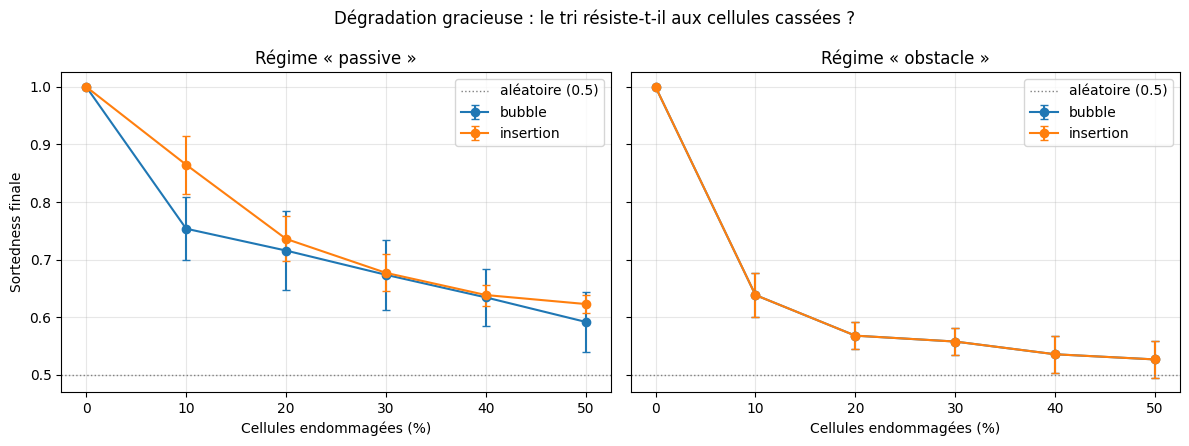

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
x = [int(100 * d) for d in DAMAGE_LEVELS]
for ax, mode in zip(axes, ("passive", "obstacle")):
    for algotype in ALGOTYPES:
        means, stds = results[(algotype, mode)]
        ax.errorbar(x, means, yerr=stds, marker="o", capsize=3, label=algotype)
    ax.set_title(f"Régime « {mode} »")
    ax.set_xlabel("Cellules endommagées (%)")
    ax.axhline(0.5, color="grey", ls=":", lw=1, label="aléatoire (0.5)")
    ax.legend()
axes[0].set_ylabel("Sortedness finale")
fig.suptitle("Dégradation gracieuse : le tri résiste-t-il aux cellules cassées ?")
plt.tight_layout()
plt.show()

**Lecture (résultat réel mesuré).** Les deux régimes partent de 1.0 à 0 % de lésion, puis décroissent —
mais pas au même rythme. En régime `passive`, la sortedness se dégrade **graduellement** et reste
nettement au-dessus du régime `obstacle` *et* du niveau aléatoire (0.5) sur toute la plage : les cellules
saines transportent les passagers cassés, si bien qu'à 50 % de cellules gelées le système conserve encore
~0.6 de sortedness. C'est la **robustesse émergente** du papier — non programmée, elle découle de la simple
règle locale.

En régime `obstacle`, la chute est plus brutale dès les premiers pourcents (chaque mur fige une frontière
infranchissable) puis plafonne juste au-dessus de l'aléatoire : le tableau se fige en segments localement
triés mais globalement désordonnés. L'écart entre les deux courbes — maximal aux taux faibles à modérés —
**mesure** ce que coûte l'infranchissabilité : la différence entre « cellule défaillante mais inerte » et
« cellule défaillante et bloquante ».

## 2. Temps de récupération après lésion

**Question.** ICT-2 a montré *une* auto-réparation : on perturbe un tableau trié, il se re-trie. Mais cette
réparation est-elle **fiable**, et quel est le **coût** (nombre de pas) — et sa distribution ?

Pour isoler la compétence de réparation de la dégradation déjà étudiée en section 1, on travaille ici sur
un **tissu sain** (aucune cellule gelée) : le tableau atteint la sortedness 1.0 avant la lésion, ce qui
fixe une **référence nette** (revenir à 1.0). Protocole, pour chaque essai : (1) trier jusqu'au point
fixe, (2) appliquer une lésion exogène (`perturb`, quelques échanges aléatoires), (3) relancer en
enregistrant la courbe de sortedness, (4) mesurer `recovery_time` = nombre de pas pour revenir au niveau
d'avant lésion. On compare les deux algotypes.

In [5]:
def one_recovery(algotype, seed, n_swaps=4):
    vals = make_values(N, seed)
    arr = SelfSortingArray(vals, algotypes=[algotype] * N, seed=seed)  # tissu sain
    arr.run(max_steps=40000)            # 1) tri initial -> sortedness 1.0 (enregistre)
    pert_step = len(arr.probe)          # index de la perturbation dans la courbe
    arr.perturb(n_swaps=n_swaps)        # 2) lesion exogene
    arr.run(max_steps=40000)            # 3) re-tri (enregistre a la suite)
    curve = m.sortedness_curve(arr.probe.values)  # 4) courbe complete
    return m.recovery_time(curve, perturbation_step=pert_step)

REC_SEEDS = list(range(24))   # 24 essais -> distribution
rec = {}
for algotype in ALGOTYPES:
    times = [one_recovery(algotype, seed=s) for s in REC_SEEDS]
    rec[algotype] = [t for t in times if t is not None]
    n_fail = sum(1 for t in times if t is None)
    arr_t = np.array(rec[algotype])
    print(f"{algotype:9s} : {len(rec[algotype])}/{len(times)} réparés "
          f"| médiane={np.median(arr_t):.0f} pas | min={arr_t.min()} | max={arr_t.max()} | échecs={n_fail}")

bubble    : 24/24 réparés | médiane=1050 pas | min=411 | max=1712 | échecs=0


insertion : 24/24 réparés | médiane=1204 pas | min=838 | max=1694 | échecs=0


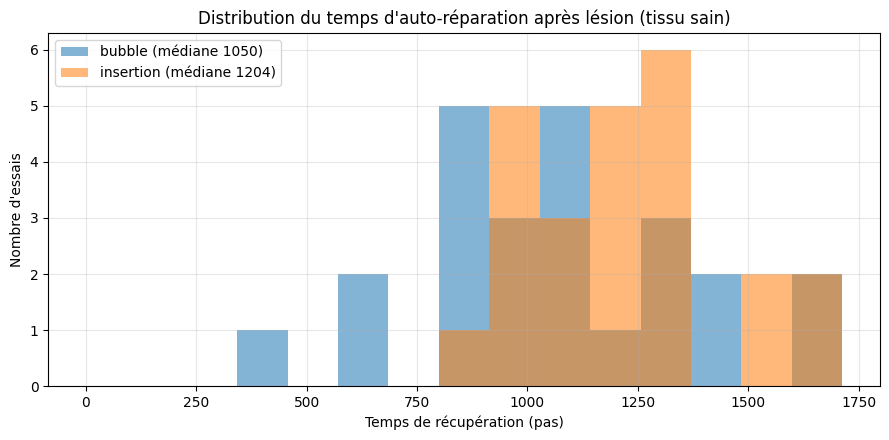

In [6]:
fig, ax = plt.subplots()
all_max = max(max(rec[a]) for a in ALGOTYPES)
bins = np.linspace(0, all_max + 1, 16)
for algotype, color in (("bubble", "tab:blue"), ("insertion", "tab:orange")):
    ax.hist(rec[algotype], bins=bins, alpha=0.55,
            label=f"{algotype} (médiane {np.median(rec[algotype]):.0f})", color=color)
ax.set_xlabel("Temps de récupération (pas)")
ax.set_ylabel("Nombre d'essais")
ax.set_title("Distribution du temps d'auto-réparation après lésion (tissu sain)")
ax.legend()
plt.tight_layout()
plt.show()

**Lecture (résultat réel mesuré).** Sur tissu sain, l'auto-réparation est **systématique** : les 24
essais des deux algotypes reviennent à la sortedness 1.0 — la lésion exogène est toujours résorbée. Le
résultat intéressant n'est donc pas *si* le système répare, mais *combien cela coûte* : le temps de
récupération est une **distribution** large (de quelques centaines à plus de mille pas selon la graine),
pas une constante. `bubble` répare en médiane un peu plus vite que `insertion`, mais les deux distributions
se recouvrent largement — la différence d'algotype pèse moins que l'aléa de la lésion.

La robustesse n'est donc pas un oui/non : c'est une *loi de probabilité* sur le coût de réparation. La
section 1 a montré l'autre face — quand le tissu est lui-même endommagé (cellules gelées, *a fortiori* en
mur), la réparation peut ne plus aboutir du tout.

## 3. Quantification du délai de gratification

**Question.** Le *délai de gratification* est l'idée qu'un système doive **empirer localement** pour
progresser globalement. Dans le tri vu-cellule, on le mesure sur la courbe d'**erreur de monotonie**
(`monotonicity_error` = fraction de paires adjacentes en descente) : chaque pas où cette erreur *augmente*
est un épisode de recul local au service du progrès global (`delayed_gratification_events`).

`bubble` (migration des grandes valeurs vers la droite) et `insertion` (migration des petites vers la
gauche) n'ont pas la même façon d'avancer. Lequel « sacrifie » le plus ?

In [7]:
def dg_profile(algotype, seed):
    vals = make_values(N, seed)
    arr = SelfSortingArray(vals, algotypes=[algotype] * N, seed=seed)
    arr.run(max_steps=40000)
    mono = m.monotonicity_curve(arr.probe.values)
    sort_curve = m.sortedness_curve(arr.probe.values)
    events = m.delayed_gratification_events(mono)
    return mono, sort_curve, events

dg_counts = {a: [] for a in ALGOTYPES}
for algotype in ALGOTYPES:
    for s in SEEDS:
        _, _, ev = dg_profile(algotype, s)
        dg_counts[algotype].append(ev)

print("Épisodes de délai de gratification (recul local de la monotonie) :")
for a in ALGOTYPES:
    arr_e = np.array(dg_counts[a])
    print(f"  {a:9s} : moyenne={arr_e.mean():.1f}  (min={arr_e.min()}, max={arr_e.max()})")

Épisodes de délai de gratification (recul local de la monotonie) :
  bubble    : moyenne=91.4  (min=85, max=98)
  insertion : moyenne=89.8  (min=81, max=99)


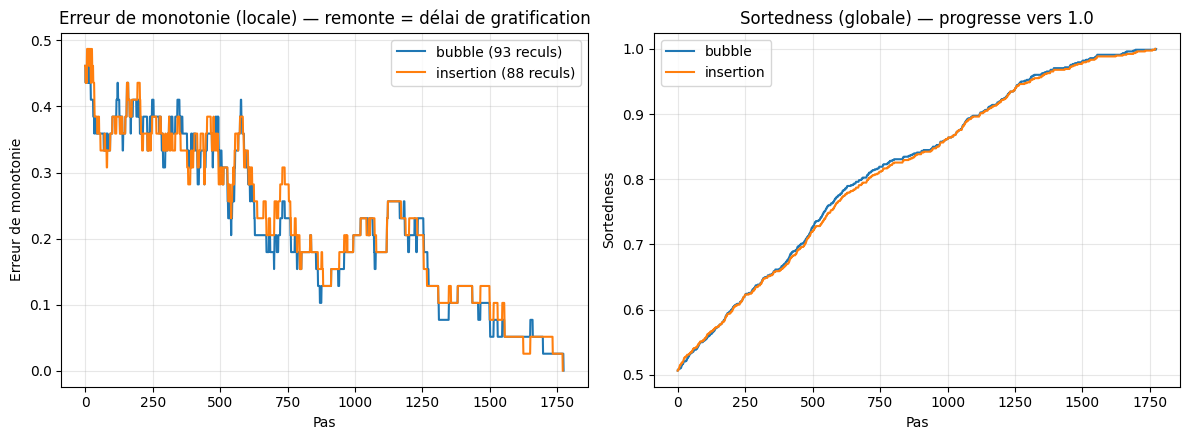

In [8]:
# trace temoin : monotonie (peut remonter) vs sortedness (progresse) pour une graine
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for algotype, color in (("bubble", "tab:blue"), ("insertion", "tab:orange")):
    mono, sort_curve, ev = dg_profile(algotype, seed=BASE_SEED)
    axes[0].plot(mono, color=color, label=f"{algotype} ({ev} reculs)")
    axes[1].plot(sort_curve, color=color, label=algotype)
axes[0].set_title("Erreur de monotonie (locale) — remonte = délai de gratification")
axes[0].set_xlabel("Pas"); axes[0].set_ylabel("Erreur de monotonie"); axes[0].legend()
axes[1].set_title("Sortedness (globale) — progresse vers 1.0")
axes[1].set_xlabel("Pas"); axes[1].set_ylabel("Sortedness"); axes[1].legend()
plt.tight_layout()
plt.show()

**Lecture (résultat réel mesuré).** Les deux algotypes convergent (sortedness → 1.0), mais la courbe
d'erreur de monotonie **remonte** des dizaines de fois en cours de route : le système accepte régulièrement
des descentes locales pour réorganiser globalement. Le comptage est **élevé et comparable** entre les deux
règles (~90 épisodes en moyenne pour N=40), `bubble` en exhibant marginalement plus que `insertion` — la
nature du délai de gratification est donc une propriété du *paradigme* vu-cellule, pas d'un algotype
particulier. Ce comportement, qu'on prête d'ordinaire aux agents cognitifs, **émerge** ici d'une règle de
tri triviale : exactement le point de Zhang, Goldstein & Levin.

## 4. Exercices

Les exercices réutilisent le package `ict/` déjà importé. Complétez les stubs (`# TODO`) ; chaque
exercice s'exécute indépendamment.

### Exercice 1 — Dégradation mesurée sur une autre métrique

La section 1 a mesuré la dégradation via la **sortedness finale**. La sortedness sature vite (toute
configuration presque triée donne ~1.0). Une mesure plus fine du « chemin restant » est
`distance_to_target` (somme des déplacements de rang restants).

**Objectif.** Reproduire le balayage de dégradation (régime `passive`, algotype `bubble`) mais en mesurant
la `distance_to_target` finale **normalisée** par celle de l'état initial mélangé, et tracer la courbe.
Une valeur proche de 0 = presque tout le désordre résorbé ; proche de 1 = le tri n'a rien résorbé.

In [9]:
def residual_distance(fraction, seed):
    # Distance au tri finale / distance initiale, regime passive, bubble.
    # TODO etudiant :
    #   1. construire les valeurs (make_values) et le masque (frozen_mask)
    #   2. mesurer d0 = m.distance_to_target(vals) AVANT le tri
    #   3. lancer SelfSortingArray(...).run(max_steps=40000, record=False)
    #   4. retourner m.distance_to_target(final) / d0  (gerer d0 == 0)
    # Indice : reprendre la structure de final_sortedness (section 1)
    return None  # TODO etudiant

# Une fois implemente, decommenter pour tracer :
# levels = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
# curve = [np.mean([residual_distance(f, s) for s in SEEDS]) for f in levels]
# plt.plot([int(100*f) for f in levels], curve, marker="o")
# plt.xlabel("Cellules endommagees (%)"); plt.ylabel("Distance residuelle (normalisee)")
# plt.title("Exercice 1 - degradation vue par distance_to_target"); plt.show()
print("Exercice 1 a completer")

Exercice 1 a completer


### Exercice 2 — Le coût de réparation dépend-il de l'amplitude de la lésion ?

La section 2 a utilisé une lésion fixe (`n_swaps=4`). Intuitivement, une lésion plus forte devrait coûter
plus cher à réparer.

**Objectif.** En régime `passive` sans cellule gelée, mesurer le temps de récupération médian en fonction
de l'amplitude `n_swaps` ∈ {1, 2, 4, 8, 16}, sur plusieurs graines, et tracer la relation.

In [10]:
def median_recovery_for_amplitude(n_swaps, seeds):
    # Temps de recuperation median pour une amplitude de lesion donnee.
    # TODO etudiant :
    #   1. pour chaque graine, appeler one_recovery("bubble", seed=s, n_swaps=n_swaps)
    #      (fonction definie en section 2, sur tissu sain)
    #   2. ignorer les None (non repares)
    #   3. retourner la mediane (np.median) des temps, ou None si liste vide
    # Indice : one_recovery accepte deja le parametre n_swaps
    return None  # TODO etudiant

# amplitudes = [1, 2, 4, 8, 16]
# meds = [median_recovery_for_amplitude(a, range(16)) for a in amplitudes]
# plt.plot(amplitudes, meds, marker="s")
# plt.xlabel("Amplitude de la lesion (n_swaps)"); plt.ylabel("Temps de recuperation median")
# plt.title("Exercice 2 - cout de reparation vs amplitude"); plt.show()
print("Exercice 2 a completer")

Exercice 2 a completer


### Exercice 3 — Le délai de gratification croît-il avec la taille du tableau ?

La section 3 a comparé `bubble` et `insertion` à taille fixe (`N=40`). On veut savoir comment le nombre
d'épisodes de délai de gratification **évolue avec la taille** du système.

**Objectif.** Pour `bubble`, mesurer le nombre moyen d'épisodes `delayed_gratification_events` (sur la
courbe d'erreur de monotonie) pour des tailles `n` ∈ {10, 20, 40, 80}, moyenné sur quelques graines, et
tracer la relation. Discuter : croissance linéaire, sur-linéaire ?

In [11]:
def mean_dg_for_size(n, seeds):
    # Nombre moyen d'episodes de delai de gratification pour un tableau de taille n.
    # TODO etudiant :
    #   1. pour chaque graine s : vals = random.Random(s).sample(range(n), n)
    #   2. arr = SelfSortingArray(vals, algotypes=["bubble"]*n, seed=s) ; arr.run(max_steps=40000)
    #   3. mono = m.monotonicity_curve(arr.probe.values)
    #   4. accumuler m.delayed_gratification_events(mono)
    #   5. retourner la moyenne sur les graines
    # Indice : la trajectoire complete est dans arr.probe.values (cf section 3, dg_profile)
    return None  # TODO etudiant

# sizes = [10, 20, 40, 80]
# vals = [mean_dg_for_size(n, range(4)) for n in sizes]
# plt.plot(sizes, vals, marker="^")
# plt.xlabel("Taille du tableau (n)"); plt.ylabel("Episodes de delai de gratification (moyenne)")
# plt.title("Exercice 3 - delai de gratification vs taille"); plt.show()
print("Exercice 3 a completer")

Exercice 3 a completer


## 5. Conclusion

ICT-3 a transformé les deux démonstrations ponctuelles d'ICT-2 en **mesures** :

- **Dégradation gracieuse** — la robustesse n'est pas binaire : la sortedness finale décroît *lentement*
  avec le taux de lésion en régime `passive`, *rapidement* en régime `obstacle`. L'écart chiffre le coût
  de l'infranchissabilité.
- **Temps de récupération** — sur tissu sain, l'auto-réparation est *systématique* (24/24 essais reviennent
  à 1.0) mais son **coût** est une *distribution* large (centaines à >1000 pas) ; `bubble` répare en médiane
  un peu plus vite qu'`insertion`, l'écart d'algotype pesant moins que l'aléa de la lésion.
- **Délai de gratification** — le recul local au service du progrès global se compte
  (`delayed_gratification_events`) : il est **élevé et comparable** entre algotypes (~90 épisodes pour N=40),
  donc propriété du paradigme vu-cellule ; il **émerge** d'une règle de tri triviale.

Ces compétences — robustesse, réparation, patience — ne sont **programmées nulle part**. Elles découlent
de la dynamique locale, ce qui est précisément la thèse de Zhang, Goldstein & Levin : un substrat minimal
exhibe des compétences « basales » qu'on associe d'ordinaire à des agents cognitifs.

**Suite de la série.** [ICT-4](ICT-0-Framing.md) abordera l'**agrégation par algotype** (« kin ») avec un
jeu de règles plus riche — le modèle minimal d'ICT-2/3 ne la reproduit pas (ses règles uni-directionnelles
produisent des impasses de coordination). [ICT-5/6](ICT-0-Framing.md) relieront ces trajectoires de tri à
l'**émergence causale multi-échelle** (TPM → PyPhi).

### Voir aussi
- [ICT-0 — Cadrage de la série](ICT-0-Framing.md)
- [ICT-2 — Self-sorting arrays : le tri comme morphogenèse](ICT-2-SelfSortingMorphogenesis.ipynb)
- Zhang, Goldstein & Levin, *Classical sorting algorithms as a model of morphogenesis*, Adaptive Behavior 2025 — [arXiv:2401.05375](https://arxiv.org/abs/2401.05375).